# Logistic Regression and SVM Hometask

In [98]:
import warnings
from sklearn.exceptions import ConvergenceWarning

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.datasets import (
    load_breast_cancer,
    make_moons
)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    precision_recall_curve
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC

In [94]:
warnings.filterwarnings("ignore", category=ConvergenceWarning)
np.random.seed(42)

ink = "#2f2a34"
paper = "#f6f1e7"
panel = "#efe4d6"
grid = "#ccbda8"

sns.set_theme(
    context="talk",
    style="ticks",
    palette=["#ff6b6b", "#1982c4", "#ffd166", "#2a9d8f", "#6a4c93"],
    rc={
        "figure.facecolor": paper,
        "axes.facecolor": panel,
        "savefig.facecolor": paper,
        "axes.edgecolor": ink,
        "axes.labelcolor": ink,
        "text.color": ink,
        "xtick.color": ink,
        "ytick.color": ink,
        "grid.color": grid,
        "grid.linestyle": ":",
        "grid.alpha": 0.55,
        "axes.grid": True,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlelocation": "left",
        "axes.titleweight": "bold",
        "axes.titlepad": 14,
        "legend.frameon": True,
        "legend.facecolor": "#fbf7f0",
        "legend.edgecolor": grid,
    },
)

surface_cmap = sns.blend_palette(
    ["#1f2041", "#4b3f72", "#417b5a", "#f4d35e", "#ee964b"], as_cmap=True
)
warm_cmap = sns.blend_palette(["#fff1d0", "#f4a261", "#e76f51"], as_cmap=True)
cool_cmap = sns.blend_palette(["#e0fbfc", "#4ea8de", "#293241"], as_cmap=True)
class_colors = ["#ff6b6b", "#1982c4", "#6a4c93", "#2a9d8f"]


def metric_frame(y_true, y_pred, y_score=None):
    rows = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    if y_score is not None:
        rows["roc_auc"] = roc_auc_score(y_true, y_score)
    return pd.DataFrame(
        {"metric": list(rows.keys()), "value": list(rows.values())}
    )


def make_grid(X, n=300, padding=1.0):
    x0_min, x0_max = X[:, 0].min() - padding, X[:, 0].max() + padding
    x1_min, x1_max = X[:, 1].min() - padding, X[:, 1].max() + padding
    xx, yy = np.meshgrid(
        np.linspace(x0_min, x0_max, n),
        np.linspace(x1_min, x1_max, n),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    return xx, yy, grid


def final_estimator(model):
    return model.named_steps["model"] if isinstance(model, Pipeline) else model


def scaler_step(model):
    if isinstance(model, Pipeline):
        return model.named_steps.get("scaler")
    return None


def score_on_grid(model, grid):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(grid)[:, 1]
    scores = model.decision_function(grid)
    min_score, max_score = scores.min(), scores.max()
    return (scores - min_score) / (max_score - min_score)


def plot_surface(ax, model, X, y, title, show_support=False, levels=28):
    xx, yy, grid = make_grid(X)
    z = score_on_grid(model, grid).reshape(xx.shape)

    ax.contourf(xx, yy, z, levels=levels, cmap=surface_cmap, alpha=0.94)
    ax.contour(xx, yy, z, levels=[0.5], colors="#fffaf1", linewidths=2.2)
    sns.scatterplot(
        x=X[:, 0],
        y=X[:, 1],
        hue=y,
        palette=class_colors[: len(np.unique(y))],
        s=60,
        edgecolor="#2b1d26",
        linewidth=0.4,
        legend=False,
        ax=ax,
    )

    if show_support and hasattr(final_estimator(model), "support_vectors_"):
        sv = final_estimator(model).support_vectors_
        scaler = scaler_step(model)
        if scaler is not None:
            sv = scaler.inverse_transform(sv)
        ax.scatter(
            sv[:, 0],
            sv[:, 1],
            s=220,
            facecolors="none",
            edgecolors="#fffaf1",
            linewidths=1.8,
        )

    ax.set_title(title)
    ax.set_xlabel("feature 1")
    ax.set_ylabel("feature 2")


def plot_margin_surface(ax, model, X, y, title, show_support=True):
    xx, yy, grid = make_grid(X)
    scores = model.decision_function(grid).reshape(xx.shape)

    ax.contourf(xx, yy, scores, levels=28, cmap=surface_cmap, alpha=0.92)
    ax.contour(
        xx,
        yy,
        scores,
        levels=[-1, 0, 1],
        colors=["#f4d35e", "#fffaf1", "#4ecdc4"],
        linestyles=["--", "-", "--"],
        linewidths=[1.6, 2.3, 1.6],
    )
    sns.scatterplot(
        x=X[:, 0],
        y=X[:, 1],
        hue=y,
        palette=class_colors[: len(np.unique(y))],
        s=60,
        edgecolor="#2b1d26",
        linewidth=0.4,
        legend=False,
        ax=ax,
    )

    if show_support and hasattr(final_estimator(model), "support_vectors_"):
        sv = final_estimator(model).support_vectors_
        scaler = scaler_step(model)
        if scaler is not None:
            sv = scaler.inverse_transform(sv)
        ax.scatter(
            sv[:, 0],
            sv[:, 1],
            s=220,
            facecolors="none",
            edgecolors="#fffaf1",
            linewidths=1.8,
        )

    ax.set_title(title)
    ax.set_xlabel("feature 1")
    ax.set_ylabel("feature 2")


def annotate_bars(ax, offset=None, fmt="{:.3f}"):
    ymin, ymax = ax.get_ylim()
    delta = (ymax - ymin) * 0.02 if offset is None else offset
    for patch in ax.patches:
        value = patch.get_height()
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            value + delta,
            fmt.format(value),
            ha="center",
            va="bottom",
            fontsize=10,
        )


print("Theme loaded. Notebook ready.")


Theme loaded. Notebook ready.


## Визначення найбільшого Threshold для найкращих метрик

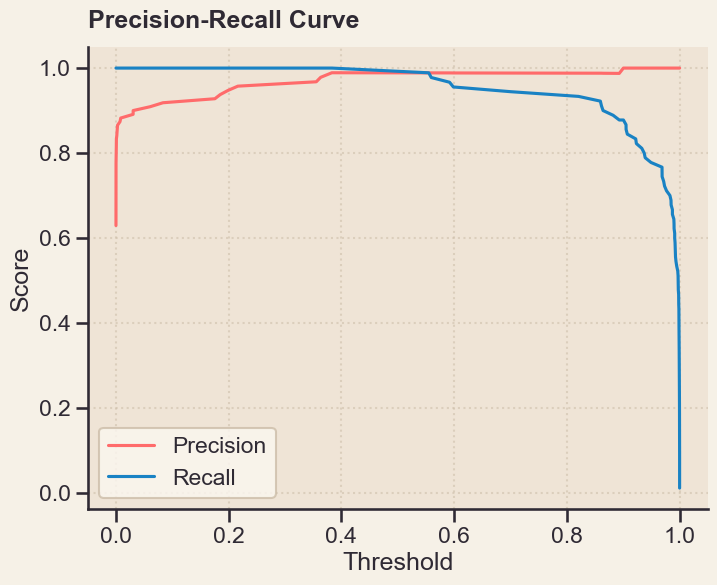

,threshold,precision,recall,f1_score
52,0.383,0.989,1.000,0.994
53,0.555,0.989,0.989,0.989
51,0.363,0.978,1.000,0.989
50,0.355,0.968,1.000,0.984
49,0.216,0.957,1.000,0.978
48,0.199,0.947,1.000,0.973
47,0.185,0.938,1.000,0.968
46,0.175,0.928,1.000,0.963
45,0.083,0.918,1.000,0.957
44,0.061,0.909,1.000,0.952


In [95]:
breast = load_breast_cancer()
X_breast = pd.DataFrame(breast.data, columns=breast.feature_names)
y_breast = pd.Series(breast.target, name="target")

X_train_b, X_test_b, Y_train_b, Y_test_b = train_test_split(
    X_breast, 
    y_breast, 
    test_size=0.25, 
    random_state=42, 
    stratify=y_breast
)

logreg = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000))
    ]
)

logreg.fit(X_train_b, Y_train_b)
pred_b = logreg.predict_proba(X_test_b)[:, 1]
precision, recall, threshold = precision_recall_curve(Y_test_b, pred_b)

threshold_analysis = pd.DataFrame({
    "threshold": threshold,
    "precision": precision[:-1],
    "recall": recall[:-1]
})
threshold_analysis["f1_score"] = (
    2 * (threshold_analysis["precision"] * threshold_analysis["recall"]) 
    / (threshold_analysis["precision"] + threshold_analysis["recall"])
)

best_recalls = threshold_analysis[threshold_analysis["recall"] >= 0.98].sort_values(by="precision", ascending=False)

plt.figure(figsize=(8, 6))
plt.plot(threshold, precision[:-1], label="Precision")
plt.plot(threshold, recall[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

display(best_recalls.head(10).round(3))

### Висновок

Як можемо побачити з результатів для threshold 0.383 або для впевненості моделів 38.3% ми отримуємо стовідсоткове визначення класу 1 та 98.9% того, що серед усіх пацієнтів, яких модель визначила як хворих, 98.9% були правильно класифіковані, що для датасету з раком молочної залози є дуже хорошим результатом, адже ми не хочемо пропустити жодного випадку раку, навіть якщо це означає, що ми будемо помилково визначати деякі випадки як рак, коли їх немає.

## Спостереження за overfiting при різних значеннях $\gamma$

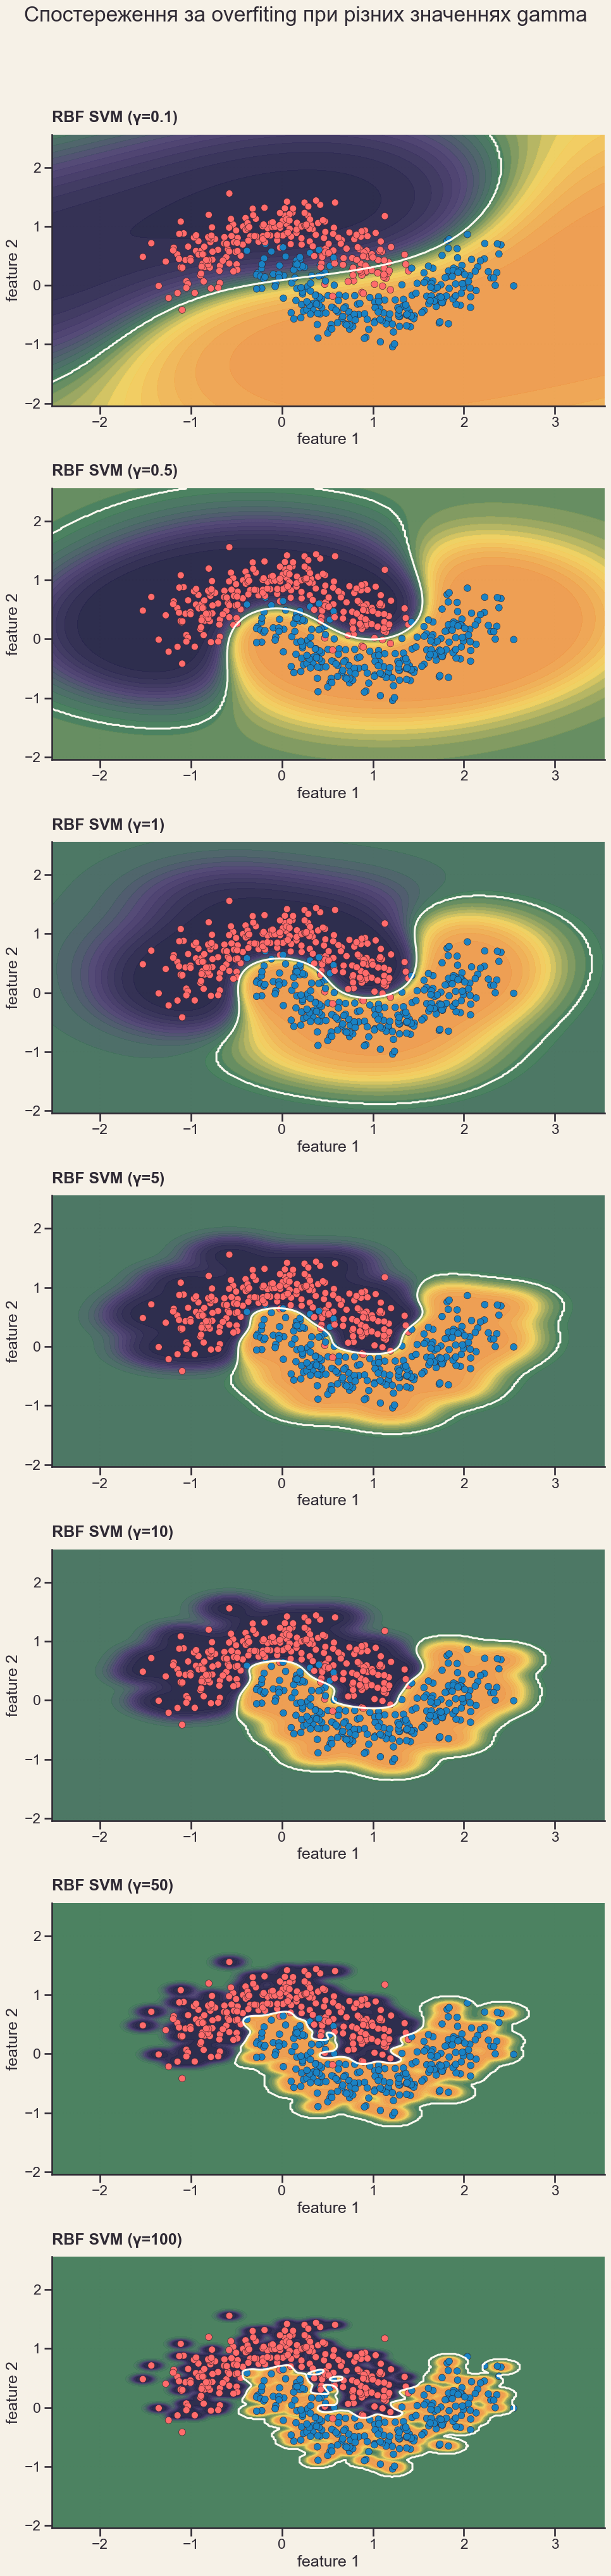

,model,train_accuracy,test_accuracy,f1_test,roc_auc_test
0,RBF SVM (γ=0.1),0.867,0.864,0.857,0.953
1,RBF SVM (γ=0.5),0.963,0.976,0.975,0.996
2,RBF SVM (γ=1),0.968,0.984,0.984,0.997
3,RBF SVM (γ=5),0.976,0.960,0.959,0.996
4,RBF SVM (γ=10),0.979,0.952,0.951,0.994
5,RBF SVM (γ=50),0.992,0.952,0.951,0.965
6,RBF SVM (γ=100),0.997,0.896,0.891,0.949


In [96]:
X_moon, y_moon = make_moons(n_samples=500, noise=0.22, random_state=42)

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_moon, 
    y_moon, 
    test_size=0.25, 
    random_state=42, 
    stratify=y_moon
)

gammas = [0.1, 0.5, 1, 5, 10, 50, 100]

moon_model = {
    f"RBF SVM (γ={g})": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("model", SVC(kernel="rbf", C=1.0, gamma=g, probability=True, random_state=42)),
        ]
    ) for g in gammas
}

fig, axes = plt.subplots(7, 1, figsize=(10, 40))
moon_rows = []

for ax, (name, model) in zip(axes, moon_model.items()):
    model.fit(X_train_m, y_train_m)

    train_pred = model.predict(X_train_m)
    test_pred = model.predict(X_test_m)

    score = model.predict_proba(X_test_m)[:, 1]

    moon_rows.append(
        {
            "model": name,
            "train_accuracy": accuracy_score(y_train_m, train_pred),
            "test_accuracy": accuracy_score(y_test_m, test_pred),
            "f1_test": f1_score(y_test_m, test_pred),
            "roc_auc_test": roc_auc_score(y_test_m, score),
            }
        )
    plot_surface(ax, model, X_moon, y_moon, name)

fig.suptitle("Спостереження за overfiting при різних значеннях gamma", y=1.02, fontsize=24)
fig.tight_layout()
plt.show()

pd.DataFrame(moon_rows).round(3)

### Висновок

Як можна побачити з результатів, при значення $\gamma$ = 1  ми отримуємо "золоту середину", що є найкращим результатом. При значенні $\gamma$ > 5 можна побачити overfitting, адже модель починає обводити кожну точку, що призвело до гарного результату на тренувальному датасеті, але поганого результату на тестовому. Це підтверджує метрика ROC AUC, що фактично показує якість моделі. При значенні $\gamma$ = 0.1 ми отриуємо результат наближений до результату при $\gamma$ = 1.

## Порівняння LinearSVC та SVC(kernel='linear')

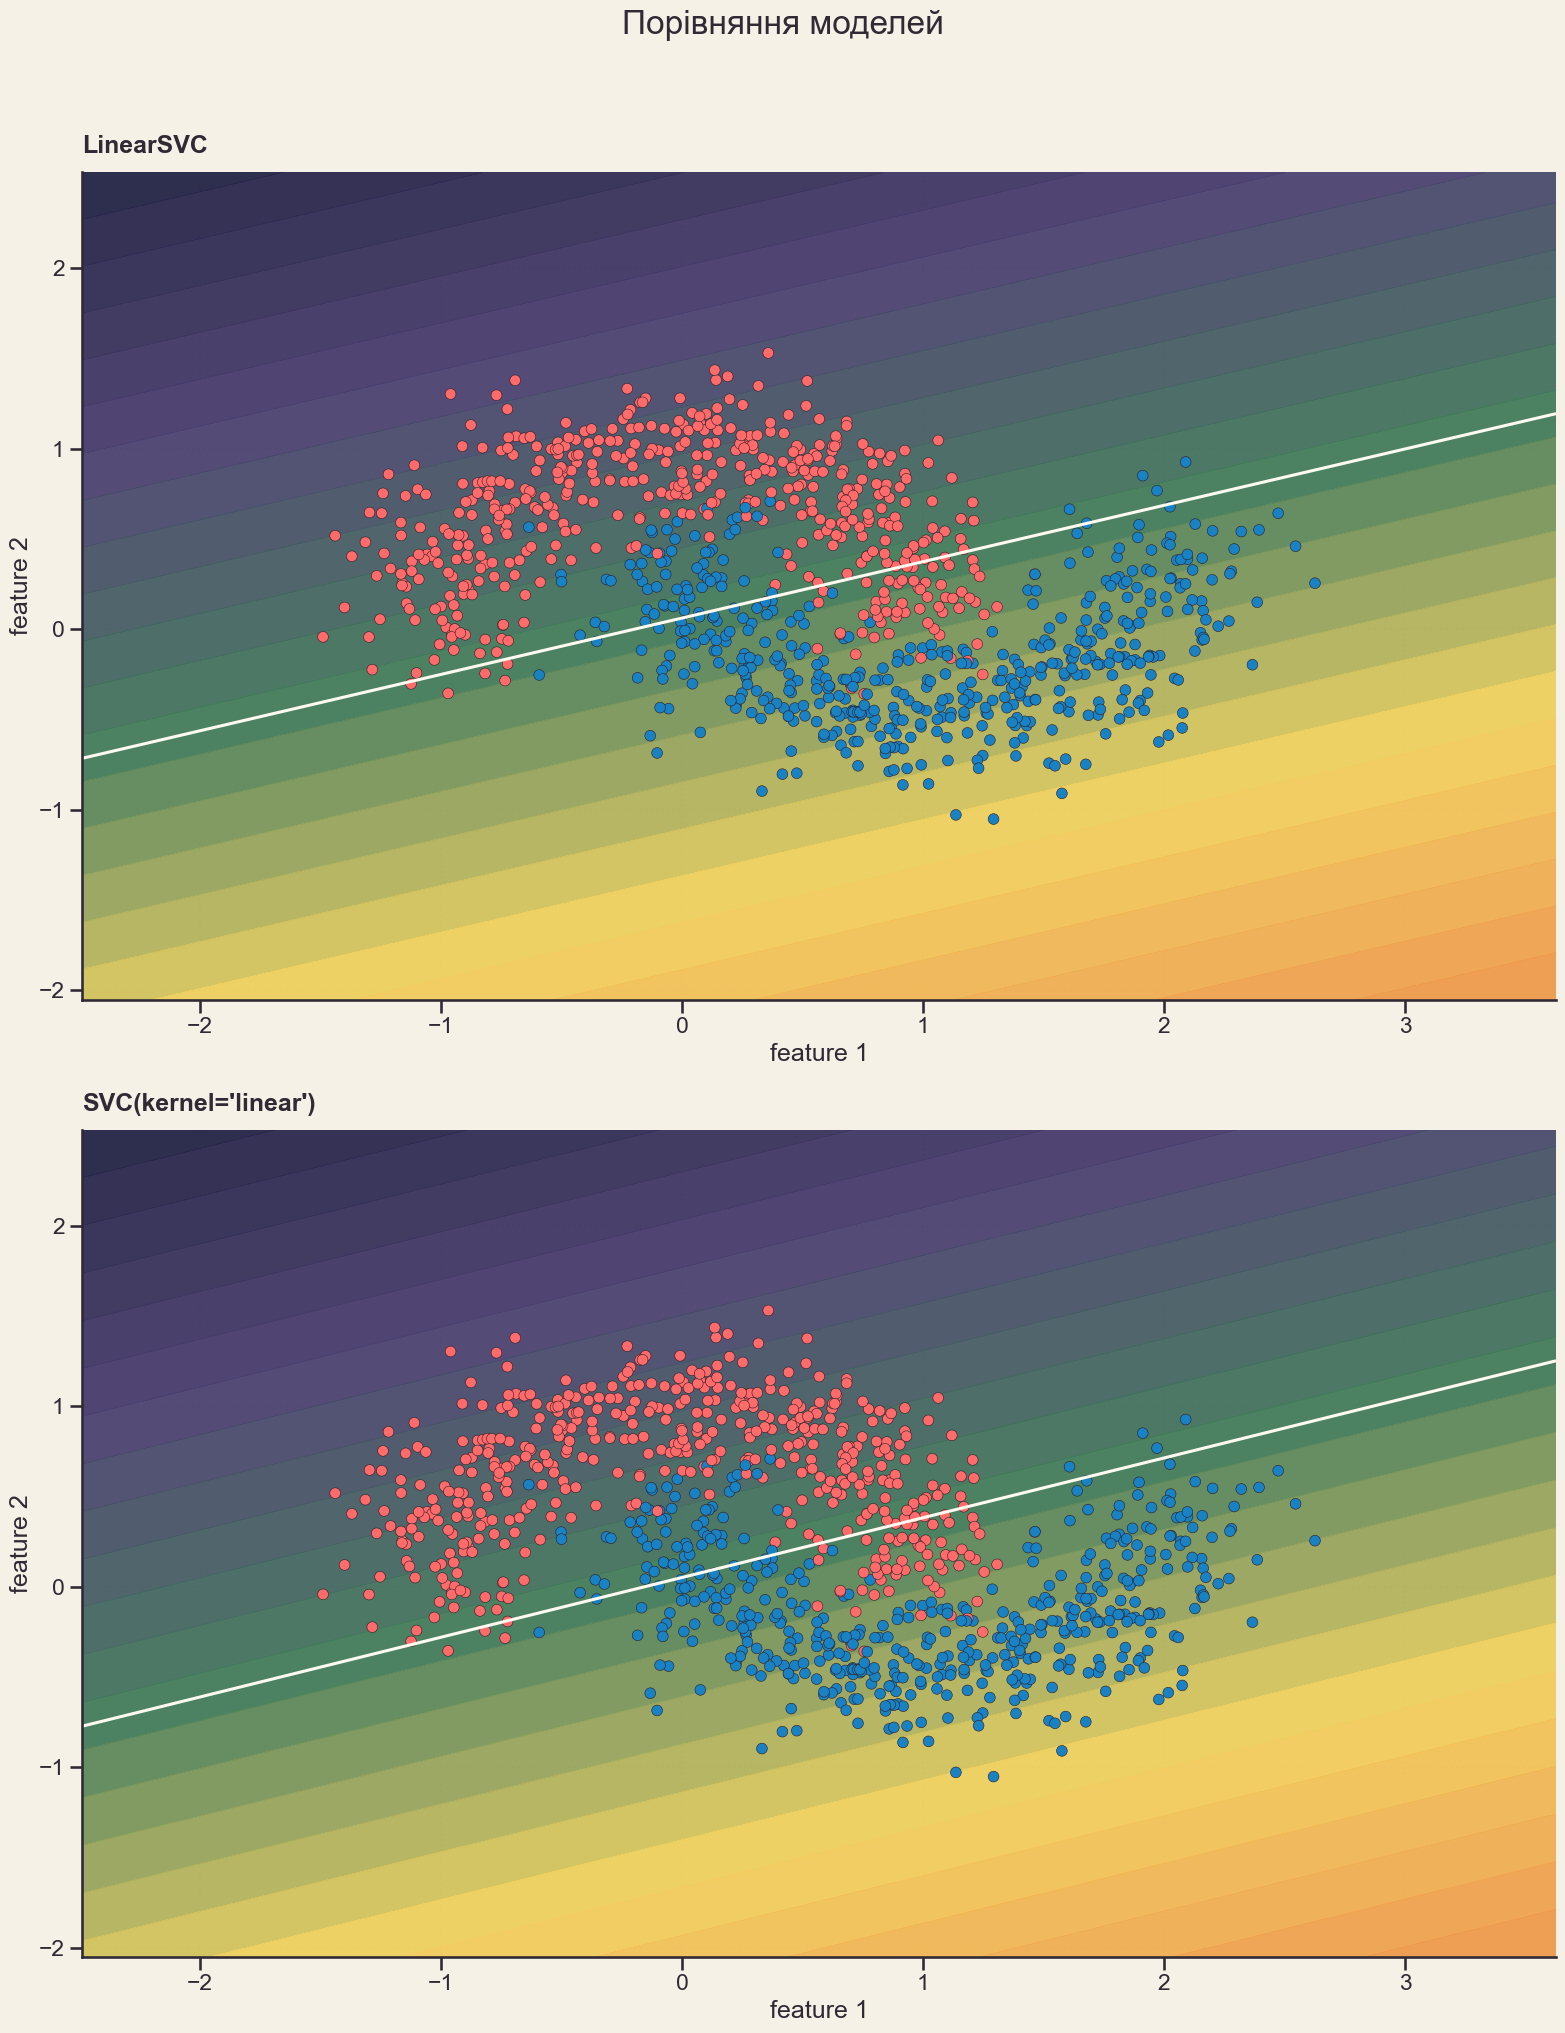

,model,runtime,train_accuracy,test_accuracy,precision_test,recall_test,f1_test
0,LinearSVC,0.009,0.851,0.9,0.924,0.872,0.897
1,SVC(kernel='linear'),0.005,0.847,0.9,0.924,0.872,0.897


In [97]:
X_moon, y_moon = make_moons(n_samples=1000, noise=0.22, random_state=42)

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_moon, 
    y_moon, 
    test_size=0.25, 
    random_state=42, 
    stratify=y_moon
)

models = {
    "LinearSVC": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("model", LinearSVC(random_state=42)),
        ]
    ),
    "SVC(kernel='linear')": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("model", SVC(kernel="linear", random_state=42)),
        ]
    ),
}

fig, axes = plt.subplots(2, 1, figsize=(16, 20))
compare_rows = []

for ax, (name, model) in zip(axes, models.items()):
    start_time = time.time()
    model.fit(X_train_m, y_train_m)
    duration = time.time() - start_time

    train_pred = model.predict(X_train_m)
    test_pred = model.predict(X_test_m)

    compare_rows.append(
        {
            "model": name,
            "runtime": duration,
            "train_accuracy": accuracy_score(y_train_m, train_pred),
            "test_accuracy": accuracy_score(y_test_m, test_pred),
            "precision_test": precision_score(y_test_m, test_pred),
            "recall_test": recall_score(y_test_m, test_pred),
            "f1_test": f1_score(y_test_m, test_pred),
            }
        )
    plot_surface(ax, model, X_moon, y_moon, name)

fig.suptitle("Порівняння моделей", y=1.02, fontsize=24)
fig.tight_layout()
plt.show()

pd.DataFrame(compare_rows).round(3)

### Висновок

Як можна побачити з результатів, на даному дата сеті, значення метрик не відрізняються за виключенням швидкості, LinearSVC в 2.5 рази швидший за SVC(kernel='linear'), та точності на тренувальному датасеті. Якщо підсумовувати, моделі демонструють однакову якість класифікації, але LinearSVC - швидший.